<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/44_model_comparison_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.metrics import accuracy_score

In [2]:
# Create Dataset

X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

print("Dataset Shape:", X.shape)

Dataset Shape: (500, 10)


In [3]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
# Create Models

models = {
    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

In [5]:
# Train and Evaluate Models

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results.append(
        [name, accuracy]
    )

    print(
        f"{name}: {accuracy:.4f}"
    )

Logistic Regression: 0.8200
Decision Tree: 0.8800
KNN: 0.8700
Random Forest: 0.9200
Gradient Boosting: 0.9200


In [6]:
# Voting Classifier

voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='hard'
)

voting.fit(
    X_train,
    y_train
)

voting_predictions = voting.predict(
    X_test
)

voting_accuracy = accuracy_score(
    y_test,
    voting_predictions
)

print(
    f"Voting Classifier: {voting_accuracy:.4f}"
)

results.append(
    ["Voting Classifier", voting_accuracy]
)

Voting Classifier: 0.8900


In [7]:
# Results DataFrame

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df

,Model,Accuracy
0,Logistic Regression,0.82
1,Decision Tree,0.88
2,KNN,0.87
3,Random Forest,0.92
4,Gradient Boosting,0.92
5,Voting Classifier,0.89


In [8]:
# Sort Results

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
4,Gradient Boosting,0.92
3,Random Forest,0.92
5,Voting Classifier,0.89
1,Decision Tree,0.88
2,KNN,0.87
0,Logistic Regression,0.82


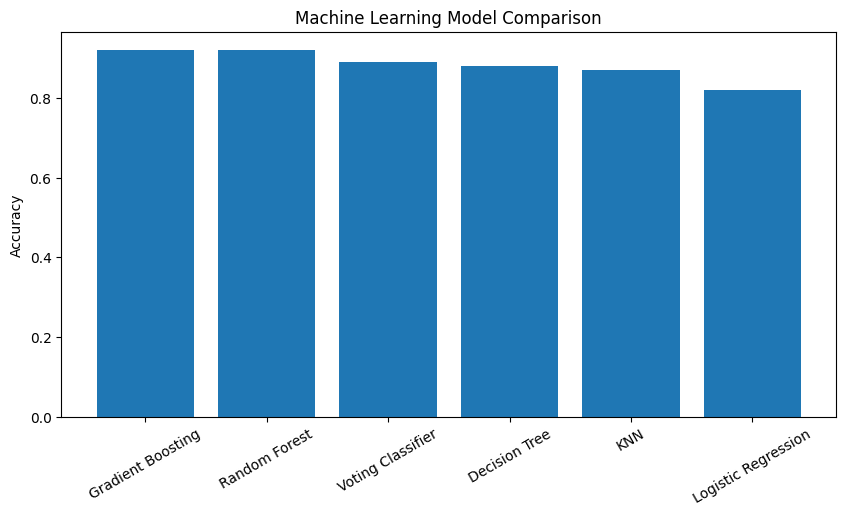

In [9]:
# Performance Comparison Graph

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=30)

plt.ylabel("Accuracy")

plt.title(
    "Machine Learning Model Comparison"
)

plt.show()

In [10]:
# Best Model

best_model = results_df.iloc[0]

print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Accuracy:",
    round(best_model["Accuracy"], 4)
)

Best Model: Gradient Boosting
Accuracy: 0.92


## Conclusion

This notebook compared multiple machine learning algorithms on the same dataset.

Observations:
- Different algorithms produced different accuracy scores.
- Ensemble methods such as Random Forest, Gradient Boosting, and Voting Classifier generally performed well.
- Simpler models like Logistic Regression provided useful baseline performance.
- Model comparison helps identify suitable algorithms for a given problem.